<a href="https://colab.research.google.com/github/akithmaaponso7-spec/northstaranalytics/blob/main/SQL_in_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages("sqldf")
install.packages("readr")
install.packages("dplyr")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(sqldf)
library(readr)
library(dplyr)
library(ggplot2)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
list.files()

[1] "northstar_dataset.zip" "sample_data"

In [ ]:
unzip("northstar_dataset.zip", exdir = "northstar_dataset")

In [ ]:
list.files("northstar_dataset", recursive = TRUE)

[1] "northstar_dataset/app_events.csv"     
 [2] "northstar_dataset/complaints.csv"     
 [3] "northstar_dataset/customers.csv"      
 [4] "northstar_dataset/data_dictionary.csv"
 [5] "northstar_dataset/deliveries.csv"     
 [6] "northstar_dataset/drivers.csv"        
 [7] "northstar_dataset/hubs.csv"           
 [8] "northstar_dataset/incidents.csv"      
 [9] "northstar_dataset/orders.csv"         
[10] "northstar_dataset/README.txt"         
[11] "northstar_dataset/vehicles.csv"

In [ ]:
csv_files <- list.files(
  "northstar_dataset",
  pattern = "\\.csv$",
  recursive = TRUE,
  full.names = TRUE
)

csv_files

[1] "northstar_dataset/northstar_dataset/app_events.csv"     
 [2] "northstar_dataset/northstar_dataset/complaints.csv"     
 [3] "northstar_dataset/northstar_dataset/customers.csv"      
 [4] "northstar_dataset/northstar_dataset/data_dictionary.csv"
 [5] "northstar_dataset/northstar_dataset/deliveries.csv"     
 [6] "northstar_dataset/northstar_dataset/drivers.csv"        
 [7] "northstar_dataset/northstar_dataset/hubs.csv"           
 [8] "northstar_dataset/northstar_dataset/incidents.csv"      
 [9] "northstar_dataset/northstar_dataset/orders.csv"         
[10] "northstar_dataset/northstar_dataset/vehicles.csv"

In [ ]:
customers <- read_csv(csv_files[grepl("customers", csv_files)])
orders <- read_csv(csv_files[grepl("orders", csv_files)])
deliveries <- read_csv(csv_files[grepl("deliveries", csv_files)])
drivers <- read_csv(csv_files[grepl("drivers", csv_files)])
vehicles <- read_csv(csv_files[grepl("vehicles", csv_files)])
hubs <- read_csv(csv_files[grepl("hubs", csv_files)])
complaints <- read_csv(csv_files[grepl("complaints", csv_files)])
incidents <- read_csv(csv_files[grepl("incidents", csv_files)])
app_events <- read_csv(csv_files[grepl("app_events", csv_files)])

Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6)

In [ ]:
head(customers)

customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NA,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


In [ ]:
head(deliveries)

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58


In [ ]:
head(complaints)

complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<chr>,<dbl>,<dbl>
CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


In [ ]:
names(customers)
names(deliveries)
names(orders)
names(drivers)
names(hubs)
names(complaints)
names(incidents)

[1] "customer_id"          "age"                  "home_zone"           
[4] "customer_type"        "signup_date"          "loyalty_score"       
[7] "app_engagement_score" "preferred_channel"    "account_status"

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

[1] "driver_id"        "base_zone"        "employment_type"  "years_experience"
[5] "training_score"   "driver_rating"    "shift_preference" "active_flag"

[1] "hub_id"         "hub_name"       "zone"           "hub_type"      
[5] "capacity_score"

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

[1] "incident_id"       "delivery_id"       "incident_type"    
[4] "reported_at"       "severity"          "resolution_status"
[7] "resolved_hours"

In [ ]:
query1 <- sqldf("
SELECT *
FROM deliveries
LIMIT 10
")

query1

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58
DL00007,O00097,D151,V037,H07,2024-01-09 13:41:00,2024-01-10 23:39:11,Delayed,32.72,0,0,4.64,17.70
DL00008,O00207,D082,V066,H03,2024-08-22 21:34:00,2024-08-22 23:22:21,OnTime,7.16,1,0,3.76,11.66
DL00009,O00297,D088,V029,H05,2024-04-12 21:33:00,2024-04-13 01:18:52,OnTime,40.23,1,0,3.70,15.78


In [ ]:
delayed_deliveries <- sqldf("
SELECT *
FROM deliveries
WHERE delivery_status = 'Delayed'
")

head(delayed_deliveries)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
2,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58
3,DL00007,O00097,D151,V037,H07,2024-01-09 13:41:00,2024-01-10 23:39:11,Delayed,32.72,0,0,4.64,17.70
4,DL00017,O01249,D002,V008,H05,2024-08-25 18:26:00,2024-08-26 03:05:42,Delayed,20.79,0,0,1.00,15.62
5,DL00028,O00087,D165,V022,H08,2024-11-12 15:52:00,2024-11-13 04:15:00,Delayed,15.53,2,0,2.70,13.05
6,DL00034,O01081,D157,V110,H04,2025-06-18 12:01:00,2025-06-19 05:14:57,Delayed,14.68,0,0,4.40,9.44


In [ ]:
delay_count <- sqldf("
SELECT delivery_status, COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
")

delay_count

delivery_status,total_deliveries
<chr>,<int>
Delayed,202
Failed,132
OnTime,616


In [ ]:
hub_delay_analysis <- sqldf("
SELECT hub_id,
       COUNT(*) AS total_deliveries,
       SUM(CASE WHEN delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_deliveries
FROM deliveries
GROUP BY hub_id
ORDER BY delayed_deliveries DESC
")

hub_delay_analysis

hub_id,total_deliveries,delayed_deliveries
<chr>,<int>,<int>
H04,127,28
H06,104,27
H02,106,26
H01,136,26
H07,115,25
H05,115,25
H03,119,23
H08,128,22


In [ ]:
hub_performance <- sqldf("
SELECT h.hub_id,
       h.hub_name,
       COUNT(d.delivery_id) AS total_deliveries,
       SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_deliveries
FROM hubs h
JOIN deliveries d
ON h.hub_id = d.hub_id
GROUP BY h.hub_id, h.hub_name
ORDER BY delayed_deliveries DESC
")

hub_performance

hub_id,hub_name,total_deliveries,delayed_deliveries
<chr>,<chr>,<int>,<int>
H04,West Gate,127,28
H06,Airport Hub,104,27
H01,North Exchange,136,26
H02,South Link,106,26
H05,Central Core,115,25
H07,Riverside Hub,115,25
H03,East Dock,119,23
H08,Midtown Relay,128,22


In [ ]:
customer_complaints <- sqldf("
SELECT c.customer_id,
       c.customer_type,
       c.home_zone,
       COUNT(co.complaint_id) AS total_complaints
FROM customers c
JOIN complaints co
ON c.customer_id = co.customer_id
GROUP BY c.customer_id, c.customer_type, c.home_zone
ORDER BY total_complaints DESC
")

customer_complaints

customer_id,customer_type,home_zone,total_complaints
<chr>,<chr>,<chr>,<int>
C0368,Consumer,North,4
C0110,Consumer,EAST,3
C0142,Consumer,SOUTH,3
C0172,Consumer,north,3
C0191,Consumer,North,3
C0242,Consumer,East,3
C0282,Consumer,RiverSide,3
C0372,Consumer,West,3
C0421,Consumer,CENTRAL,3


In [ ]:
complaints_by_customer_type <- sqldf("
SELECT c.customer_type,
       COUNT(co.complaint_id) AS total_complaints
FROM customers c
JOIN complaints co
ON c.customer_id = co.customer_id
GROUP BY c.customer_type
ORDER BY total_complaints DESC
")

complaints_by_customer_type

customer_type,total_complaints
<chr>,<int>
Consumer,242
SME,50
Enterprise,28


In [ ]:
complaints_by_zone <- sqldf("
SELECT c.home_zone,
       COUNT(co.complaint_id) AS total_complaints
FROM customers c
JOIN complaints co
ON c.customer_id = co.customer_id
GROUP BY c.home_zone
ORDER BY total_complaints DESC
")

complaints_by_zone

home_zone,total_complaints
<chr>,<int>
SOUTH,33
RiverSide,24
North,24
CENTRAL,24
East,23
north,21
Riverside,21
West,19
NORTH,19


In [ ]:
driver_incidents <- sqldf("
SELECT d.driver_id,
       d.base_zone,
       d.employment_type,
       d.years_experience,
       d.training_score,
       COUNT(i.incident_id) AS total_incidents
FROM drivers d
JOIN deliveries de
ON d.driver_id = de.driver_id
JOIN incidents i
ON de.delivery_id = i.delivery_id
GROUP BY d.driver_id, d.base_zone, d.employment_type, d.years_experience, d.training_score
ORDER BY total_incidents DESC
")

driver_incidents

driver_id,base_zone,employment_type,years_experience,training_score,total_incidents
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
D039,AIRPORT,Contract,7,86.1,7
D087,north,Contract,13,73.3,6
D004,Airport,PartTime,13,88.9,5
D026,NORTH,PartTime,4,84.9,5
D132,South,Contract,8,77.6,5
D146,Airport,Contract,1,NA,5
D002,Central,FullTime,4,42.4,4
D032,East,PartTime,6,81.5,4
D037,north,PartTime,7,63.9,4


In [ ]:
delivery_complaint_analysis <- sqldf("
SELECT d.delivery_status,
       COUNT(co.complaint_id) AS total_complaints
FROM deliveries d
JOIN orders o
ON d.order_id = o.order_id
JOIN complaints co
ON o.customer_id = co.customer_id
GROUP BY d.delivery_status
ORDER BY total_complaints DESC
")

delivery_complaint_analysis

delivery_status,total_complaints
<chr>,<int>
OnTime,437
Delayed,138
Failed,94


In [ ]:
hub_performance <- sqldf("
SELECT h.hub_id,
       h.hub_name,
       h.zone,
       COUNT(d.delivery_id) AS total_deliveries,
       SUM(CASE WHEN d.delivery_status != 'Completed' THEN 1 ELSE 0 END) AS unsuccessful_deliveries
FROM hubs h
JOIN deliveries d
ON h.hub_id = d.hub_id
GROUP BY h.hub_id, h.hub_name, h.zone
ORDER BY unsuccessful_deliveries DESC
")

hub_performance

hub_id,hub_name,zone,total_deliveries,unsuccessful_deliveries
<chr>,<chr>,<chr>,<int>,<int>
H01,North Exchange,North,136,136
H08,Midtown Relay,Central,128,128
H04,West Gate,West,127,127
H03,East Dock,East,119,119
H05,Central Core,Central,115,115
H07,Riverside Hub,Riverside,115,115
H02,South Link,South,106,106
H06,Airport Hub,Airport,104,104


In [ ]:
hub_rating_analysis <- sqldf("
SELECT h.hub_name,
       h.zone,
       ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
       COUNT(d.delivery_id) AS total_deliveries
FROM hubs h
JOIN deliveries d
ON h.hub_id = d.hub_id
GROUP BY h.hub_name, h.zone
ORDER BY avg_customer_rating ASC
")

hub_rating_analysis

hub_name,zone,avg_customer_rating,total_deliveries
<chr>,<chr>,<dbl>,<int>
Central Core,Central,3.67,115
North Exchange,North,3.84,136
Airport Hub,Airport,3.88,104
Midtown Relay,Central,3.88,128
Riverside Hub,Riverside,3.88,115
East Dock,East,3.90,119
West Gate,West,3.92,127
South Link,South,3.95,106


In [ ]:
route_override_analysis <- sqldf("
SELECT h.hub_name,
       h.zone,
       SUM(d.manual_route_override_count) AS total_manual_overrides,
       ROUND(AVG(d.manual_route_override_count), 2) AS avg_manual_overrides
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.hub_name, h.zone
ORDER BY total_manual_overrides DESC
")

route_override_analysis

hub_name,zone,total_manual_overrides,avg_manual_overrides
<chr>,<chr>,<dbl>,<dbl>
Midtown Relay,Central,142,1.11
North Exchange,North,140,1.03
Riverside Hub,Riverside,121,1.05
West Gate,West,111,0.87
Central Core,Central,109,0.95
East Dock,East,106,0.89
South Link,South,97,0.92
Airport Hub,Airport,95,0.91


In [ ]:
optimised_query <- sqldf("
SELECT delivery_id,
       order_id,
       hub_id,
       delivery_status,
       manual_route_override_count,
       customer_rating_post_delivery
FROM deliveries
WHERE delivery_status != 'Completed'
")

optimised_query

delivery_id,order_id,hub_id,delivery_status,manual_route_override_count,customer_rating_post_delivery
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
DL00001,O00938,H05,Failed,1,3.07
DL00002,O00004,H02,OnTime,1,5.00
DL00003,O00639,H02,OnTime,0,4.98
DL00004,O00313,H02,Delayed,0,4.18
DL00005,O00844,H01,OnTime,1,4.18
DL00006,O00029,H03,Delayed,0,1.57
DL00007,O00097,H07,Delayed,0,4.64
DL00008,O00207,H03,OnTime,1,3.76
DL00009,O00297,H05,OnTime,1,3.70


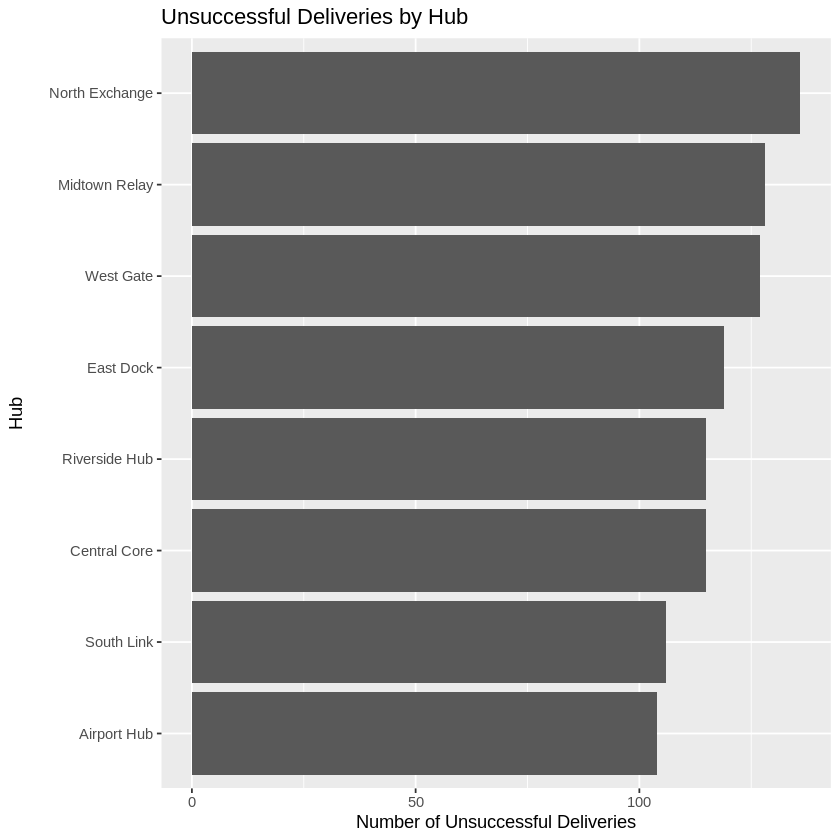

In [ ]:
ggplot(hub_performance, aes(x = reorder(hub_name, unsuccessful_deliveries),
                            y = unsuccessful_deliveries)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Unsuccessful Deliveries by Hub",
    x = "Hub",
    y = "Number of Unsuccessful Deliveries"
  )

In [ ]:
write_csv(customer_complaints, "customer_complaints_sql_output.csv")
write_csv(complaints_by_customer_type, "complaints_by_customer_type.csv")
write_csv(complaints_by_zone, "complaints_by_zone.csv")
write_csv(driver_incidents, "driver_incidents_sql_output.csv")
write_csv(delivery_complaint_analysis, "delivery_complaint_analysis.csv")
write_csv(hub_performance, "hub_performance_sql_output.csv")